## Load the dataset


In [5]:
from sklearn.datasets import load_iris
import pandas as pd

iris=load_iris()
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']=iris.target
df['species_name']=df['species'].map({0: 'setosa' , 1: 'versicolor', 2: 'virginica'})

## Exploratory Data Analysis (EDA)

In [7]:
print(df.shape)   
print(df.dtypes)  # confirm numeric columns are float64, species is int


(150, 6)
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object


In [8]:
print(df.isnull().sum()) # check for missing values
print(df.describe())   # mean, std, min, max, quartiles for each measurement

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000

## Visualizations


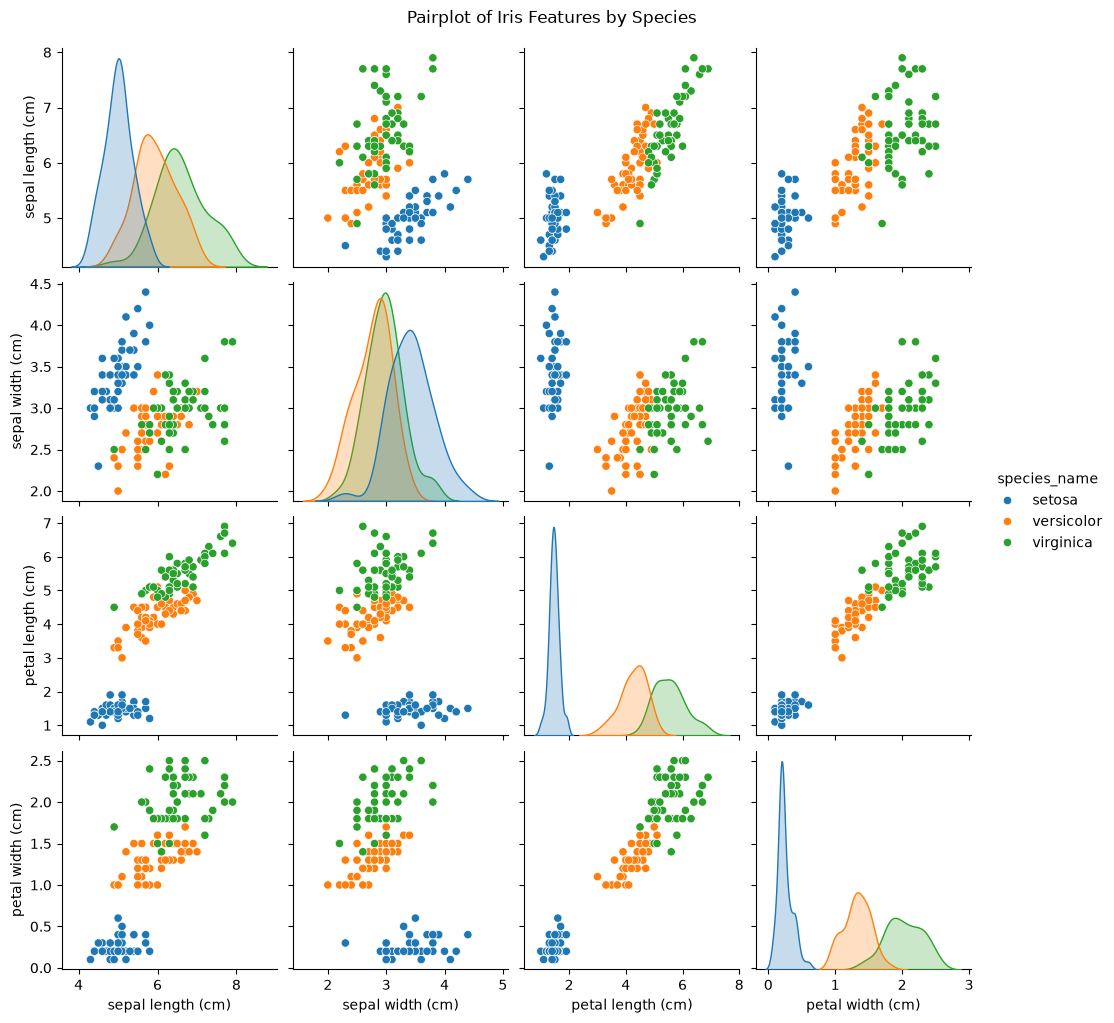

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species_name', vars=iris.feature_names)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()



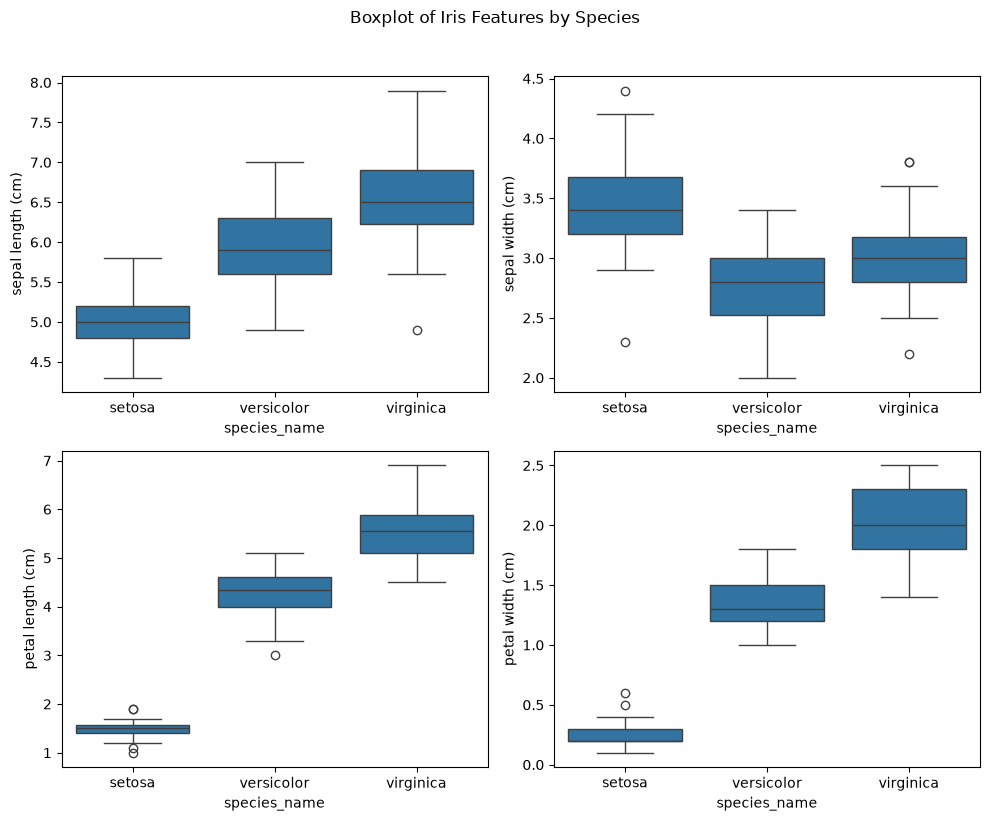

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, feature in enumerate(iris.feature_names):
    sns.boxplot(data=df, x='species_name', y=feature, ax=axes[i//2, i%2])
    plt.suptitle('Boxplot of Iris Features by Species', y=1.02)
plt.tight_layout()
plt.show()

## Train/test split

In [15]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Training

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

## Evaluating models

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))
    print()

--- Logistic Regression ---
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


--- KNN ---
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00      

All three models were evaluated on the same 30-sample test set. Logistic Regression achieved 96.67% accuracy, misclassifying one Versicolor as Virginica. K-Nearest Neighbors (KNN) achieved 100% accuracy, with a perfect confusion matrix and no misclassifications across any of the three species. Decision Tree achieved 93.33% accuracy, the weakest of the three, with two errors — one Versicolor predicted as Virginica and one Virginica predicted as Versicolor.

KNN is selected as the best-performing model because it was the only classifier to achieve perfect precision, recall, and F1-score (1.00) across all three species, with zero misclassifications. This makes sense given the dataset: Iris classes — especially Setosa — are tightly clustered in feature space, and KNN's distance-based approach exploits that clustering directly rather than relying on a single linear decision boundary (as Logistic Regression does) or greedy axis-aligned splits (as Decision Tree does). The errors made by the other two models were consistently between Versicolor and Virginica — the two species that visibly overlap in the pairplot — confirming that KNN handled the one genuinely ambiguous region of the data more effectively than the alternatives